# Image processing notebook: From overlap corrected to transmission 

### 00 - exp 1XX acquisition 00

##  Initial settings

### Import libraries
Import all the required libraries

In [25]:
import sys
sys.path.append(r'..\01_Functions')
from step_functions import *
from dict_functions import *
from proc_functions import *
from img_functions import *
%matplotlib inline

### Select directories
Select the source directory. This directory is where the images **after** the overlap correction were saved.
Select the destination directory. Here is where the transmission images are going to be saved.

In [26]:
# %load select_directory('src_dir')
src_dir = r"J:\700 Campaigns - internal\2021\PSI21_10NI_updated_framework\01_Overlap_corrected\exp102"

In [27]:
# %load select_directory('dst_dir')
dst_dir = r"J:\700 Campaigns - internal\2021\PSI21_10NI_updated_framework\02_Transmission_results\exp102_stats"

### Check folders to process

In [28]:
stack_dict = prep_stack_dict(src_dir)
for key in stack_dict.keys():
    print(key)

000_ob_00
000_temp_00_p20_ob
001_ref_00
001_temp_00_p20_batch01
002_temp_00_p20_batch02
003_temp_00_p20_batch03
004_temp_01_p10_ob
005_temp_01_p10_batch01
006_temp_01_p10_batch02
007_temp_01_p10_batch03
008_temp_02_p0_ob
009_temp_02_p0_batch01
010_temp_02_p0_batch02
011_temp_02_p0_batch03
012_temp_03_m10_ob
013_temp_03_m10_batch01
014_temp_03_m10_batch02
015_temp_03_m10_batch03
016_temp_04_m23_ob
017_temp_04_m23_batch01
018_temp_04_m23_batch02
019_temp_04_m23_batch03
020_temp_05_m15_ob
021_temp_05_m15_batch01
022_temp_05_m15_batch02
023_temp_05_m15_batch03
024_temp_06_m5_ob
025_temp_06_m5_batch01
026_temp_06_m5_batch02
027_temp_06_m5_batch03
028_temp_07_p5_ob
029_temp_07_p5_batch01
030_temp_07_p5_batch02
031_temp_07_p5_batch03
032_temp_08_p17_ob
033_temp_08_p17_batch01
034_temp_08_p17_batch02
035_temp_08_p17_batch03
036_temp_09_p30_ob
037_temp_09_p30_batch01
038_temp_09_p30_batch02
039_temp_09_p30_batch03
040_temp_10_p40_ob
041_temp_10_p40_batch01
042_temp_10_p40_batch02
043_temp_10_p4

In [29]:
proc_folder = ['003_temp_00_p20_batch03']
ref_folder = ['001_ref_00']

## Process the reference folder (if not done before)
Or in case it is not previously saved.

In case the parameters and ref_dict are stored in the global variables, you can load them with : `%store -r "name given"`

It is **important** to not process the images fully before having played with them to find the right parameters (there is a notebook called playgound todo this)

In [6]:
#%store -r exp_param
ref_dir =  r"J:\700 Campaigns - internal\2021\PSI21_10NI_updated_framework\02_Transmission_results\exp102"
ref_dict = read_saved_dict (ref_dir, proc_folder = ['001_ref_00'])

Reading Images: 100%|████████████████████████████| 1/1 [00:00<00:00,  2.13it/s]


In [30]:
ref_param = {}
nca_ref = [388, 10, 59, 488]

add_to_dict(ref_param, ['threshold', 'nca', 'ws_filter_size'], [0, nca_ref, 3])

In [31]:
ref_seq =  [stack_averaging,
            scrubbing_correction_dict,
            ws_filter,
            outlier_removal,
            SBKG_correction_dict]

In [32]:
BB_mask = get_img(os.path.dirname(src_dir) + '/mask_ref.fits')
add_to_dict(ref_param,['BB_mask'], [BB_mask])

ref_dict = full_processing (src_dir, dst_dir, proc_folder = ref_folder, sequence = ref_seq, 
                 proc_parameters = ref_param, img_name = 'intensity_avg', save = True)

Reading Images: 100%|████████████████████████████| 3/3 [00:15<00:00,  5.10s/it]


Experiment 001_ref_00 in process...


Processing SBKG Correction: 100%|████████████████| 1/1 [00:39<00:00, 39.71s/it]


Saving images as a single acquisition


Writing Images: 100%|████████████████████████████| 1/1 [00:03<00:00,  3.50s/it]


Total time: 270s


## Gettinging an NCA

In [33]:
test_folder01 = ['003_temp_00_p20_batch03']

img_dict, _ = testing_mode_step (src_dir, proc_folder = test_folder01, keep_acq_numb = 1)

Reading Images: 100%|████████████████████████████| 3/3 [00:01<00:00,  2.19it/s]


In [34]:
img_batch = avg_frames_dict (img_dict[test_folder01[0]], output_type = 'img')

In [35]:
# %load select_rois(img_batch01, list_rois = ['nca'])
nca = [390, 10, 59, 488]

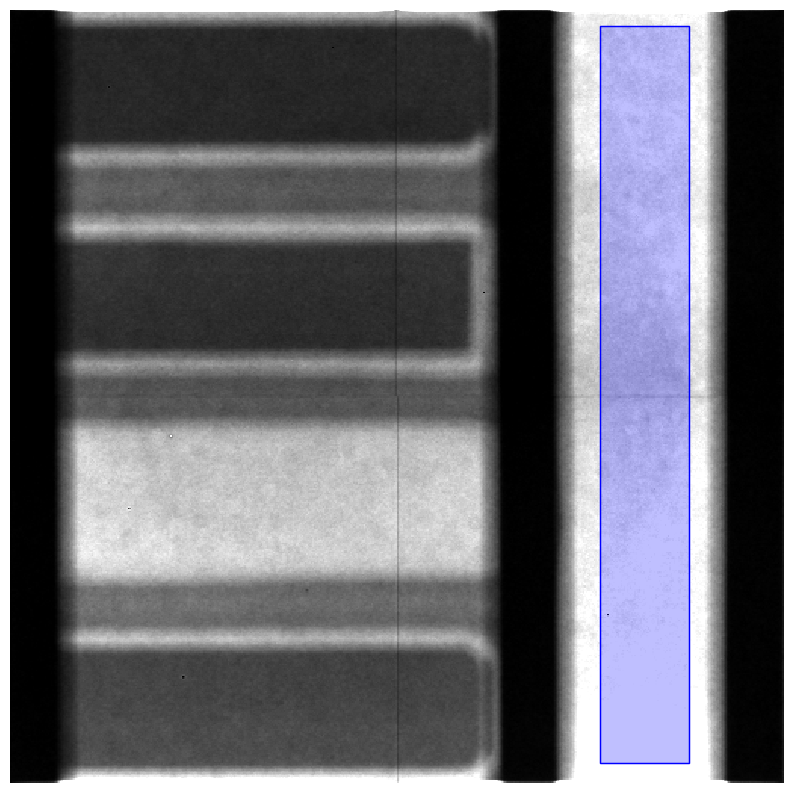

In [36]:
show_img(img_batch[0], dr = [(nca, 'blue')], cmap='gray')

## Base parameters and Sequence

In [37]:
exp_param = {}

add_to_dict(exp_param, ['nca', 'threshold', 'use_ref', 'ref_dict', 'ws_filter_size'], [nca, 0, True, ref_dict, 3])

In [38]:
exp_seq =  [#stack_averaging,
            scrubbing_correction_dict,
            ws_filter,
            outlier_removal,
            SBKG_correction_dict,
            intensity_correction_dict,
            referencing_dict]

## Exp102 Processing

In [39]:
BB_mask = get_img(os.path.dirname(src_dir) + '/mask_batch03.fits')
add_to_dict(exp_param,['BB_mask'], [BB_mask])

exp_dict = full_processing (src_dir, dst_dir, proc_folder = proc_folder, sequence = exp_seq, 
                 proc_parameters = exp_param, img_name = 'transmission_noavg', save = True)

Reading Images: 100%|████████████████████████████| 3/3 [00:09<00:00,  3.26s/it]


Experiment 003_temp_00_p20_batch03 in process...


Processing Referencing Correction: 100%|█████████| 6/6 [00:01<00:00,  4.24it/s]


Saving images as a time series of acquisitions


Writing Images: 100%|████████████████████████████| 6/6 [00:21<00:00,  3.59s/it]


Total time: 788s
